In [1]:
from all_imports import *

In [2]:
# 1. Filter for delivered orders only and drop rows with missing dates
delivered_orders = orders_df[orders_df['order_status'] == 'delivered'].copy()
delivered_orders.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date'], inplace=True)

# 2. Convert to datetime
delivered_orders['order_delivered_customer_date'] = pd.to_datetime(delivered_orders['order_delivered_customer_date'])
delivered_orders['order_estimated_delivery_date'] = pd.to_datetime(delivered_orders['order_estimated_delivery_date'])

# 3. Calculate delivery delta in days
# A positive number means the order arrived LATE. A negative number means it arrived EARLY.
delivered_orders['delivery_delta_days'] = (
    delivered_orders['order_delivered_customer_date'] - 
    delivered_orders['order_estimated_delivery_date']
).dt.total_seconds() / (24 * 3600)

# 4. Create a categorical label for analysis
delivered_orders['delivery_status'] = np.where(
    delivered_orders['delivery_delta_days'] > 0, 'Late', 'On-Time/Early'
)

In [3]:
# Aggregate reviews to order level (in case of rare multiple reviews per order)
order_reviews_agg = orderReviews_df.groupby('order_id')['review_score'].mean().reset_index()

# Get customer state per order
order_customers = delivered_orders[['order_id', 'customer_id']].merge(
    customers_df[['customer_id', 'customer_state']], on='customer_id', how='left'
)

# Map categories to items, then aggregate at the order level
items_with_cats = orderItems_df.merge(products_df[['product_id', 'product_category_name']], on='product_id', how='left')
items_with_cats = items_with_cats.merge(productCategoryNameTranslation_df, on='product_category_name', how='left')

# For orders with multiple categories, we can take the primary one (or combine them)
# Here, we take the first category per order to keep it 1:1
order_categories = items_with_cats.groupby('order_id')['product_category_name_english'].first().reset_index()

# Build the Master DataFrame
master_df = delivered_orders[['order_id', 'delivery_delta_days', 'delivery_status']].merge(
    order_reviews_agg, on='order_id', how='inner'
).merge(
    order_customers[['order_id', 'customer_state']], on='order_id', how='left'
).merge(
    order_categories, on='order_id', how='left'
)

In [4]:
overall_impact = master_df.groupby('delivery_status')['review_score'].agg(['mean', 'count'])
print(overall_impact)

                     mean  count
delivery_status                 
Late             2.566506   7661
On-Time/Early    4.294292  88163


In [5]:
# Group by state and product category
regional_impact = master_df.groupby(['customer_state', 'product_category_name_english']).apply(
    lambda x: pd.Series({
        'avg_score': x['review_score'].mean(),
        'late_rate_pct': (x['delivery_status'] == 'Late').mean() * 100,
        'late_avg_score': x[x['delivery_status'] == 'Late']['review_score'].mean()
    }),
    include_groups=False
).reset_index().sort_values('late_rate_pct', ascending=False)

# Clean up category string format (replace underscores with spaces & capitalize words)
regional_impact['product_category_name_english'] = (
    regional_impact['product_category_name_english']
    .str.replace('_', ' ')
    .str.title()
)

In [6]:
category_impact = master_df.groupby('product_category_name_english').apply(
    lambda x: pd.Series({
        'order_volume': len(x),
        'late_rate_pct': (x['delivery_status'] == 'Late').mean() * 100,
        'avg_score': x['review_score'].mean()
    }),
    include_groups=False
).loc[lambda df: df['order_volume'] > 500].sort_values('late_rate_pct', ascending=False)

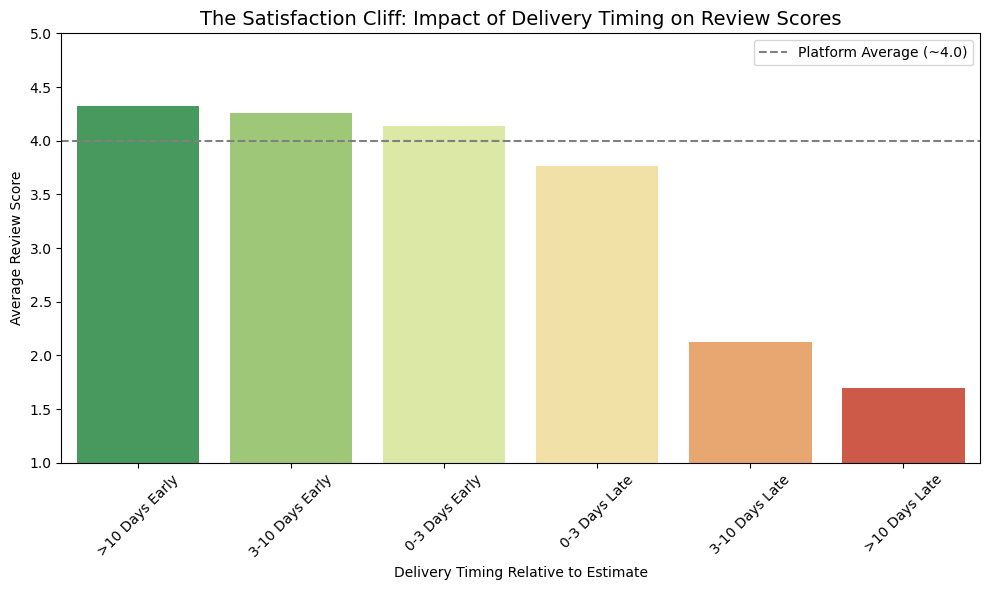

In [7]:
# Create logical bins for delivery timing
bins = [-np.inf, -10, -3, 0, 3, 10, np.inf]
labels = ['>10 Days Early', '3-10 Days Early', '0-3 Days Early', '0-3 Days Late', '3-10 Days Late', '>10 Days Late']
master_df['delivery_bin'] = pd.cut(master_df['delivery_delta_days'], bins=bins, labels=labels)

# Calculate average score per bin (Warning 1 Fixed)
bin_scores = master_df.groupby('delivery_bin', observed=False)['review_score'].mean().reset_index()

# Plot
plt.figure(figsize=(10, 6))
# Warning 2 Fixed below (added hue and legend=False)
sns.barplot(data=bin_scores, x='delivery_bin', y='review_score', hue='delivery_bin', palette='RdYlGn_r', legend=False)
plt.axhline(4.0, color='grey', linestyle='--', label='Platform Average (~4.0)')
plt.title('The Satisfaction Cliff: Impact of Delivery Timing on Review Scores', fontsize=14)
plt.xlabel('Delivery Timing Relative to Estimate')
plt.ylabel('Average Review Score')
plt.ylim(1, 5)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Assuming 'regional_impact' from the previous step is loaded and has a 'volume' column
regional_impact['volume'] = master_df.groupby('customer_state').size()

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=regional_impact, 
    x='late_rate_pct', 
    y='avg_score', 
    size='volume', 
    sizes=(50, 1000), 
    alpha=0.7, 
    color='b'
)

# Annotate specific outlier states
for i, row in regional_impact.iterrows():
    # Only label states with high volume or extreme late rates to avoid clutter
    if row['volume'] > 2000 or row['late_rate_pct'] > 15:
        plt.text(row['late_rate_pct'] + 0.2, row['avg_score'], i, fontsize=9)

plt.title('Regional Performance: Delivery Delays vs. Customer Satisfaction', fontsize=14)
plt.xlabel('Percentage of Late Deliveries (%)')
plt.ylabel('Average Review Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

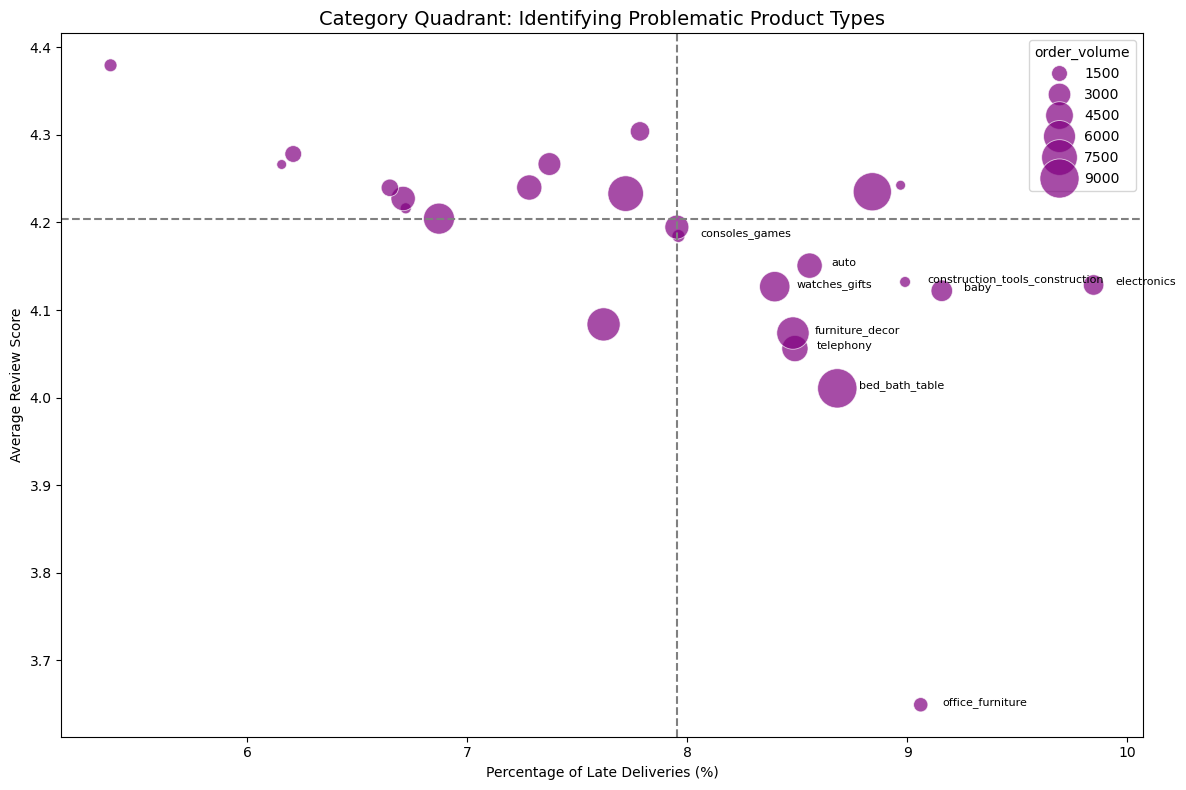

In [10]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=category_impact, 
    x='late_rate_pct', 
    y='avg_score', 
    size='order_volume', 
    sizes=(50, 800), 
    alpha=0.7, 
    color='purple'
)

# Add quadrant lines based on median performance
plt.axvline(category_impact['late_rate_pct'].median(), color='grey', linestyle='--')
plt.axhline(category_impact['avg_score'].median(), color='grey', linestyle='--')

# Annotate the worst offenders (Bottom Right Quadrant: High Late Rate, Low Score)
worst_offenders = category_impact[
    (category_impact['late_rate_pct'] > category_impact['late_rate_pct'].median()) & 
    (category_impact['avg_score'] < category_impact['avg_score'].median())
]

for category, row in worst_offenders.iterrows():
    plt.text(row['late_rate_pct'] + 0.1, row['avg_score'], category, fontsize=8)

plt.title('Category Quadrant: Identifying Problematic Product Types', fontsize=14)
plt.xlabel('Percentage of Late Deliveries (%)')
plt.ylabel('Average Review Score')
plt.tight_layout()
plt.show()

In [32]:
# 1. Safely aggregate the geolocation coordinates by zip code prefix
geo_agg = geolocation_df.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].mean().reset_index()

# 2. Get the zip code for each order by merging with customers_df
order_locations = delivered_orders[['order_id', 'customer_id']].merge(
    customers_df[['customer_id', 'customer_zip_code_prefix']], on='customer_id', how='left'
)

# 3. Add the zip code to our existing master_df
master_geo_df = master_df.merge(order_locations[['order_id', 'customer_zip_code_prefix']], on='order_id', how='inner')

# 4. Merge the latitude and longitude coordinates safely
master_geo_df = master_geo_df.merge(
    geo_agg, 
    left_on='customer_zip_code_prefix', 
    right_on='geolocation_zip_code_prefix', 
    how='left'
)

# Drop any rows where coordinates couldn't be mapped
master_geo_df.dropna(subset=['geolocation_lat', 'geolocation_lng'], inplace=True)

In [45]:
import folium
from folium.plugins import HeatMap

# Filter data (e.g., late deliveries)
late_deliveries = master_geo_df[master_geo_df['delivery_status'] == 'Late']

# Prepare [lat, lng] array
heat_data = late_deliveries[['geolocation_lat', 'geolocation_lng']].values.tolist()

# Approximate bounding box coordinates for Brazil
min_lat, max_lat = -34.0, 6.0    # Southernmost to Northernmost
min_lon, max_lon = -74.0, -34.0  # Westernmost to Easternmost

# Initialize map centered on Brazil (using standard tile layer to avoid API key requirements)
brazil_map = folium.Map(
    location=[-14.2350, -51.9253], 
    zoom_start=4,
    zoom_control=False,
    min_zoom=4,           # Locks the minimum zoom
    max_zoom=10,           # Locks the maximum zoom
    max_bounds=True,      # Activates the draggable bounding box limit
    min_lat=min_lat,      # Sets the Southern border
    max_lat=max_lat,      # Sets the Northern border
    min_lon=min_lon,      # Sets the Western border
    max_lon=max_lon       # Sets the Eastern border
)


# Add HeatMap overlay
HeatMap(
    heat_data, 
    radius=10, 
    blur=15, 
    min_opacity=0.6,
    gradient={0.4: 'yellow', 0.7: 'orange', 1.0: 'red'}
).add_to(brazil_map)

# Add Title Header
title_html = '''
             <h3 align="center" style="font-size:16px"><b>Heatmap of Late Deliveries Across Brazil</b></h3>
             '''
brazil_map.get_root().html.add_child(folium.Element(title_html))

# Display Map
brazil_map